<a href="https://colab.research.google.com/github/tylers5x/CSE210/blob/main/week14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="progression")

df = X.copy()
df["progression"] = y

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
correlations = df.corr(numeric_only=True)["progression"].drop("progression").sort_values(ascending=False)
correlations

,progression
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062
s3,-0.394789


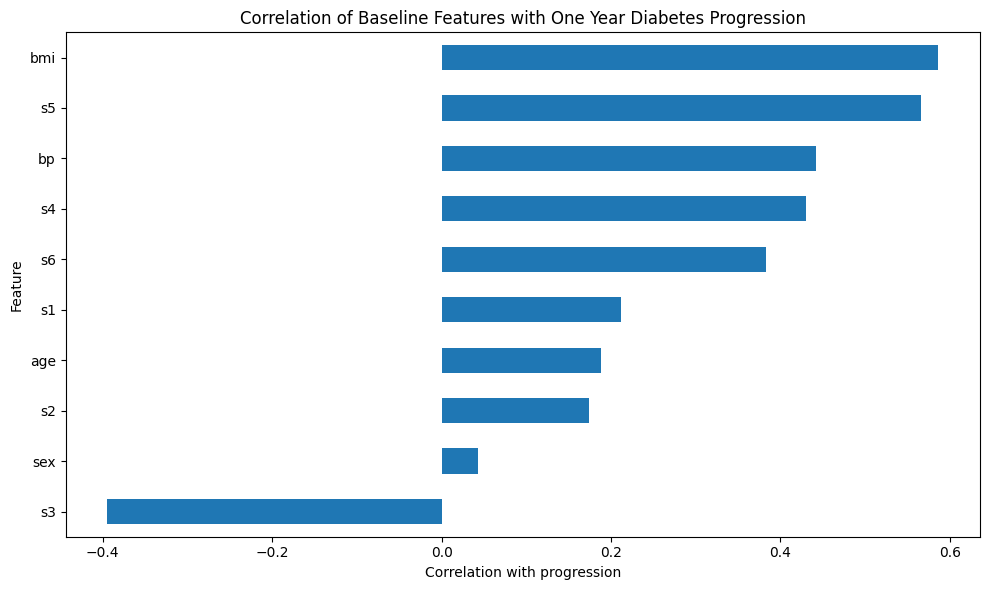

In [4]:
plt.figure(figsize=(10, 6))
correlations.sort_values().plot(kind="barh")
plt.title("Correlation of Baseline Features with One Year Diabetes Progression")
plt.xlabel("Correlation with progression")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("diabetes_corr.png", dpi=300, bbox_inches="tight")
plt.show()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    test_r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2").mean()

    results.append({
        "Model": name,
        "Test R2": round(test_r2, 3),
        "Test RMSE": round(rmse, 3),
        "Test MAE": round(mae, 3),
        "CV R2 Mean": round(cv_r2, 3)
    })

results_df = pd.DataFrame(results).sort_values(by="CV R2 Mean", ascending=False)
results_df


,Model,Test R2,Test RMSE,Test MAE,CV R2 Mean
0,Linear Regression,0.453,53.853,42.794,0.482
2,Random Forest,0.434,54.757,44.578,0.421
1,Ridge Regression,0.419,55.474,46.139,0.410


In [6]:
df["bmi_quartile"] = pd.qcut(df["bmi"], 4, labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"])
df["s5_quartile"] = pd.qcut(df["s5"], 4, labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"])

bmi_quartile_means = df.groupby("bmi_quartile", observed=False)["progression"].mean()
s5_quartile_means = df.groupby("s5_quartile", observed=False)["progression"].mean()

bmi_quartile_means, s5_quartile_means


(bmi_quartile
 Q1 Lowest     103.415929
 Q2            123.890909
 Q3            172.287037
 Q4 Highest    210.108108
 Name: progression, dtype: float64,
 s5_quartile
 Q1 Lowest      95.508621
 Q2            128.695238
 Q3            175.660714
 Q4 Highest    210.798165
 Name: progression, dtype: float64)

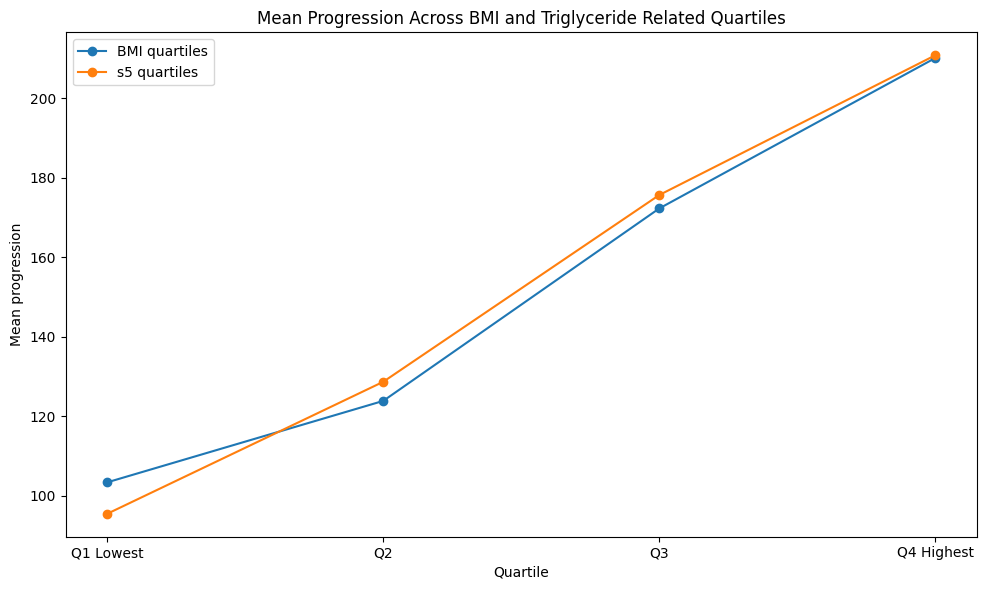

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(bmi_quartile_means.index, bmi_quartile_means.values, marker="o", label="BMI quartiles")
plt.plot(s5_quartile_means.index, s5_quartile_means.values, marker="o", label="s5 quartiles")
plt.title("Mean Progression Across BMI and Triglyceride Related Quartiles")
plt.xlabel("Quartile")
plt.ylabel("Mean progression")
plt.legend()
plt.tight_layout()
plt.savefig("diabetes_quartiles.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
top_positive = correlations.head(3)
top_negative = correlations.sort_values().head(1)
best_model = results_df.iloc[0]

summary_text = f"""
This project examined whether baseline clinical measures can help explain and predict
diabetes disease progression one year later.

The strongest positive relationships with progression were {top_positive.index[0]} (r = {top_positive.iloc[0]:.2f}),
{top_positive.index[1]} (r = {top_positive.iloc[1]:.2f}), and {top_positive.index[2]} (r = {top_positive.iloc[2]:.2f}).
The strongest negative relationship was {top_negative.index[0]} (r = {top_negative.iloc[0]:.2f}).

The best model based on cross validation was {best_model["Model"]},
with CV R2 = {best_model["CV R2 Mean"]:.3f} and test R2 = {best_model["Test R2"]:.3f}.

Average progression increased across higher BMI and s5 quartiles,
suggesting these features are useful for separating lower risk and higher risk groups.

Caveats: the sample is relatively small, the target is a progression score rather than
a diagnosis label, and these results should not be interpreted as causal.
"""

print(summary_text)



This project examined whether baseline clinical measures can help explain and predict
diabetes disease progression one year later.

The strongest positive relationships with progression were bmi (r = 0.59),
s5 (r = 0.57), and bp (r = 0.44).
The strongest negative relationship was s3 (r = -0.39).

The best model based on cross validation was Linear Regression,
with CV R2 = 0.482 and test R2 = 0.453.

Average progression increased across higher BMI and s5 quartiles,
suggesting these features are useful for separating lower risk and higher risk groups.

Caveats: the sample is relatively small, the target is a progression score rather than
a diagnosis label, and these results should not be interpreted as causal.

